# 06 - Wyniki na zbiorze testowym

W tym notebooku puszczamy nasze trzy modele (Persistence, MLP, LSTM Encoder-Decoder) na zbiorze testowym — cały rok 2025. To jest finałowa ocena, bo:

- **Test używa prognoz pogody zamiast reanalizy ERA5** - czyli dokładnie tego, co operator systemu ma do dyspozycji w realnej pracy
- Test pokrywa pełny rok, więc widzimy jak modele radzą sobie we wszystkich sezonach
- Tu się okaże, czy modele wytrenowane na "idealnej" pogodzie ERA5 nie posypią się na prognozach z błędem

Pełny opis projektu w README.

## 6.1 Konfiguracja

In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf

DATA_DIR = Path("data/processed")
MODELS_DIR = Path("models")

LOOKBACK = 48
HORIZON = 24
TARGETS = ["wi", "pv"]
EXCLUDE = ["is_test"]

print(f"TensorFlow {tf.__version__}")

TensorFlow 2.21.0


Importy i parametry takie same jak w 04/05 - kluczowe żeby okna testowe miały identyczny kształt jak treningowe, inaczej wagi sieci nie zadziałają.

## 6.2 Wczytanie modeli i scalerów

Wczytujemy modele i ich scalery zapisane w 04 (MLP) i 05 (LSTM Wariant 2). Każdy model używa swojego scalera, bo MLP miało globalny scaler na spłaszczonym wektorze, a LSTM scaler per-kolumna.

In [3]:
mlp = tf.keras.models.load_model(MODELS_DIR / "mlp.keras")
lstm = tf.keras.models.load_model(MODELS_DIR / "lstm.keras")

scaler_X_mlp = joblib.load(MODELS_DIR / "scaler_X.pkl")
scaler_y_mlp = joblib.load(MODELS_DIR / "scaler_y.pkl")

scaler_X_lstm = joblib.load(MODELS_DIR / "scaler_X_lstm.pkl")
scaler_y_lstm = joblib.load(MODELS_DIR / "scaler_y_lstm.pkl")

print(f"MLP:  {mlp.count_params():,} parametrów")
print(f"LSTM: {lstm.count_params():,} parametrów")

MLP:  875,952 parametrów
LSTM: 20,290 parametrów


E0000 00:00:1777830395.762031 3779033 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Modele załadowane. Dla pewności sprawdzamy że liczba parametrów zgadza się z tym co mieliśmy w 04 i 05.

## 6.3 Przygotowanie test setu

Test set to cały 2025 (z prognozami pogody). Ale każde okno testowe potrzebuje **48h historii** - więc dla okien z początku stycznia 2025 historia sięga w 2024 (ERA5). To dokładnie tak jak w produkcji: operator dnia poprzedniego dostaje prognozę na 24h naprzód i pyta sieć.

Bierzemy całe `dataset_full.csv` i wycinamy okres od `2024-12-30` (48h zapas) do `2025-12-31`. Z tego generujemy okna.

In [4]:
df = pd.read_csv(DATA_DIR / "dataset_full.csv", sep=";", decimal=",", parse_dates=["timestamp"]).set_index("timestamp")

df_test = df.loc["2024-12-30":"2025-12-31"]

print(f"test set: {len(df_test)} godzin")
print(f"zakres: {df_test.index.min()} -> {df_test.index.max()}")
print(f"is_test=1: {(df_test['is_test']==1).sum()} (powinno być wszystkie z 2025)")

test set: 8808 godzin
zakres: 2024-12-30 00:00:00 -> 2025-12-31 23:00:00
is_test=1: 8760 (powinno być wszystkie z 2025)


Test set ma 48h zapasu z 2024 + cały 2025. Pierwsze okno testowe startuje 1 stycznia 2025 o godz. 00:00, ostatnie 24h przed końcem 2025.

## 6.4 Generowanie okien testowych

Generujemy okna w obu formatach naraz:
- spłaszczone - dla MLP
- 3D sekwencje - dla LSTM

Robimy to w jednej funkcji żeby okna były **identyczne** dla obu modeli - porównanie będzie uczciwe.

In [5]:
HIST_COLS = [c for c in df.columns if c not in EXCLUDE]
WEATHER_COLS = [c for c in df.columns if c not in TARGETS + EXCLUDE]


def make_test_windows(data, lookback=LOOKBACK, horizon=HORIZON):
    X_flat_list, X_seq_list, y_list, ts_list = [], [], [], []
    n = len(data)

    for t in range(lookback, n - horizon):
        hist = data[HIST_COLS].iloc[t - lookback:t].values
        future_weather = data[WEATHER_COLS].iloc[t:t + horizon].values

        future_full = np.zeros((horizon, len(HIST_COLS)))
        for j, col in enumerate(HIST_COLS):
            if col in TARGETS:
                continue
            future_full[:, j] = data[col].iloc[t:t + horizon].values

        x_flat = np.concatenate([hist.flatten(), future_weather.flatten()])
        x_seq = np.concatenate([hist, future_full], axis=0)
        y = data[TARGETS].iloc[t:t + horizon].values

        X_flat_list.append(x_flat)
        X_seq_list.append(x_seq)
        y_list.append(y)
        ts_list.append(data.index[t])

    return (
        np.array(X_flat_list),
        np.array(X_seq_list),
        np.array(y_list),
        pd.DatetimeIndex(ts_list),
    )


X_test_flat, X_test_seq, y_test, ts_test = make_test_windows(df_test)

print(f"X_test_flat: {X_test_flat.shape}")
print(f"X_test_seq:  {X_test_seq.shape}")
print(f"y_test:      {y_test.shape}")
print(f"liczba okien testowych: {len(ts_test)}")
print(f"pierwszy timestamp: {ts_test.min()}")
print(f"ostatni timestamp:  {ts_test.max()}")

X_test_flat: (8736, 3264)
X_test_seq:  (8736, 72, 46)
y_test:      (8736, 24, 2)
liczba okien testowych: 8736
pierwszy timestamp: 2025-01-01 00:00:00
ostatni timestamp:  2025-12-30 23:00:00


8736 okien (8760 godzin w 2025 minus 24 ostatnie). Pierwszy timestamp to `2025-01-01 00:00`, ostatni `2025-12-30 23:00`.

## 6.5 Predykcje - Persistence

Najprostszy baseline: "to co będzie jutro o godz. X to to co było dziś o godz. X". Liczymy to bezpośrednio z danych historycznych.

In [6]:
def persistence_predict(data, ts, horizon=HORIZON):
    preds = []
    for t in ts:
        prev = data.loc[t - pd.Timedelta(hours=24):t - pd.Timedelta(hours=1), TARGETS]
        preds.append(prev.values)
    return np.array(preds)


y_pred_persistence = persistence_predict(df_test, ts_test)
print(f"persistence: {y_pred_persistence.shape}")

persistence: (8736, 24, 2)


Kształt zgodny z `y_test` - `(8736, 24, 2)`.

## 6.6 Predykcje - MLP

MLP używa spłaszczonych okien, własnego scalera. Po predykcji rozskalowujemy z powrotem do MW i zacipowujemy do nieujemnych (jak w 04).

In [7]:
X_test_flat_s = scaler_X_mlp.transform(X_test_flat)

y_pred_mlp_s = mlp.predict(X_test_flat_s, verbose=0)
y_pred_mlp = scaler_y_mlp.inverse_transform(y_pred_mlp_s)
y_pred_mlp = np.clip(y_pred_mlp, 0, None)
y_pred_mlp = y_pred_mlp.reshape(-1, HORIZON, len(TARGETS))

print(f"MLP: {y_pred_mlp.shape}")

MLP: (8736, 24, 2)


Kształt zgodny z target - gotowe do liczenia metryk.

## 6.7 Predykcje - LSTM Encoder-Decoder

LSTM ma scaler per-kolumna i potrzebuje rozdzielonych wejść (historia + przyszła pogoda).

In [8]:
def transform_3d(X, scaler):
    n, t, f = X.shape
    return scaler.transform(X.reshape(-1, f)).reshape(n, t, f)


X_test_seq_s = transform_3d(X_test_seq, scaler_X_lstm)
X_test_hist  = X_test_seq_s[:, :LOOKBACK, :]
X_test_future = X_test_seq_s[:, LOOKBACK:, :]

y_pred_lstm_s = lstm.predict([X_test_hist, X_test_future], verbose=0)
n_samples = y_pred_lstm_s.shape[0]
y_pred_lstm = scaler_y_lstm.inverse_transform(y_pred_lstm_s.reshape(-1, len(TARGETS)))
y_pred_lstm = y_pred_lstm.reshape(n_samples, HORIZON, len(TARGETS))
y_pred_lstm = np.clip(y_pred_lstm, 0, None)

print(f"LSTM: {y_pred_lstm.shape}")

LSTM: (8736, 24, 2)


Wszystkie trzy modele mają teraz predykcje o tym samym kształcie - możemy bezpośrednio porównywać.

## 6.8 Tabela porównawcza

In [9]:
def compute_metrics(y_true, y_pred, label=""):
    metrics = {}
    for i, name in enumerate(TARGETS):
        mae = mean_absolute_error(y_true[:, :, i].flatten(), y_pred[:, :, i].flatten())
        rmse = np.sqrt(mean_squared_error(y_true[:, :, i].flatten(), y_pred[:, :, i].flatten()))
        metrics[f"{name}_MAE"] = mae
        metrics[f"{name}_RMSE"] = rmse
    if label:
        print(f"\n{label}")
        for k, v in metrics.items():
            print(f"  {k}: {v:.1f} MW")
    return metrics


m_persistence = compute_metrics(y_test, y_pred_persistence, "Persistence")
m_mlp         = compute_metrics(y_test, y_pred_mlp,         "MLP")
m_lstm        = compute_metrics(y_test, y_pred_lstm,        "LSTM Encoder-Decoder")


Persistence
  wi_MAE: 1451.2 MW
  wi_RMSE: 1907.8 MW
  pv_MAE: 568.6 MW
  pv_RMSE: 1154.2 MW

MLP
  wi_MAE: 531.7 MW
  wi_RMSE: 715.2 MW
  pv_MAE: 494.4 MW
  pv_RMSE: 849.5 MW

LSTM Encoder-Decoder
  wi_MAE: 531.5 MW
  wi_RMSE: 716.5 MW
  pv_MAE: 470.1 MW
  pv_RMSE: 844.8 MW


Główne metryki testowe.

**Wyniki testowe - co widzimy:**

Persistence na teście ma podobne MAE jak na walidacji (1451 vs 1498 dla wi, 569 vs 514 dla pv) - nie używa pogody w ogóle, więc nie ma znaczenia czy podajemy ERA5 czy prognozy.

MLP i LSTM straciły jakość względem walidacji o ~25-30% MAE. To efekt który przewidywaliśmy: sieci były trenowane na "idealnej" pogodzie z reanalizy ERA5, a w teście karmimy je prognozami pogodowymi z błędem. Mimo wszystko obie sieci dramatycznie biją persistence - MLP i LSTM redukują błąd MAE wiatru z 1451 do ~532 MW (63% poprawy).

LSTM Encoder-Decoder okazał się lepszy od MLP dla PV (470 vs 494 MW, ~5% poprawy), dla wiatru praktycznie remis (oba 532 MW). Biorąc pod uwagę że LSTM ma 40× mniej parametrów (20k vs 875k), wybór architektury rekurencyjnej ma sens jako finalny model - porównywalna jakość przy znacznie mniejszej złożoności.

## 6.9 Wykres porównawczy

             wi_MAE  wi_RMSE  pv_MAE  pv_RMSE
Persistence  1451.2   1907.8   568.6   1154.2
MLP           531.7    715.2   494.4    849.5
LSTM          531.5    716.5   470.1    844.8


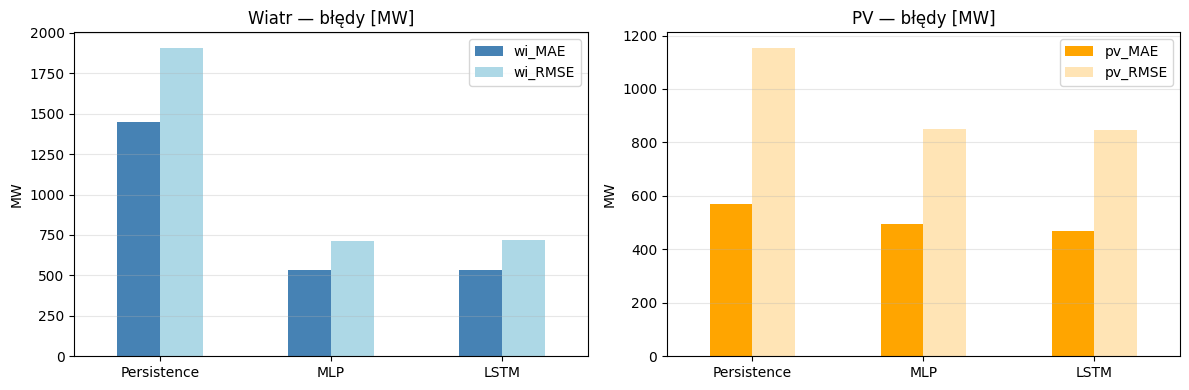

In [10]:
results = pd.DataFrame({
    "Persistence": m_persistence,
    "MLP":         m_mlp,
    "LSTM":        m_lstm,
}).T

print(results.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results[["wi_MAE", "wi_RMSE"]].plot(kind="bar", ax=axes[0], color=["steelblue", "lightblue"])
axes[0].set_title("Wiatr — błędy [MW]")
axes[0].set_ylabel("MW")
axes[0].grid(alpha=0.3, axis="y")
axes[0].tick_params(axis="x", rotation=0)

results[["pv_MAE", "pv_RMSE"]].plot(kind="bar", ax=axes[1], color=["orange", "moccasin"])
axes[1].set_title("PV — błędy [MW]")
axes[1].set_ylabel("MW")
axes[1].grid(alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Persistence wyraźnie odstaje od reszty, MLP i LSTM blisko siebie. Dla wiatru są praktycznie nierozróżnialne, dla pv LSTM zauważalnie niżej.

## 6.10 Analiza błędu w czasie - sezonowość

Sprawdzamy czy modele radzą sobie równie dobrze przez cały rok, czy są pory roku gdzie błędy są dramatycznie wyższe. Liczymy MAE per miesiąc dla każdego modelu.

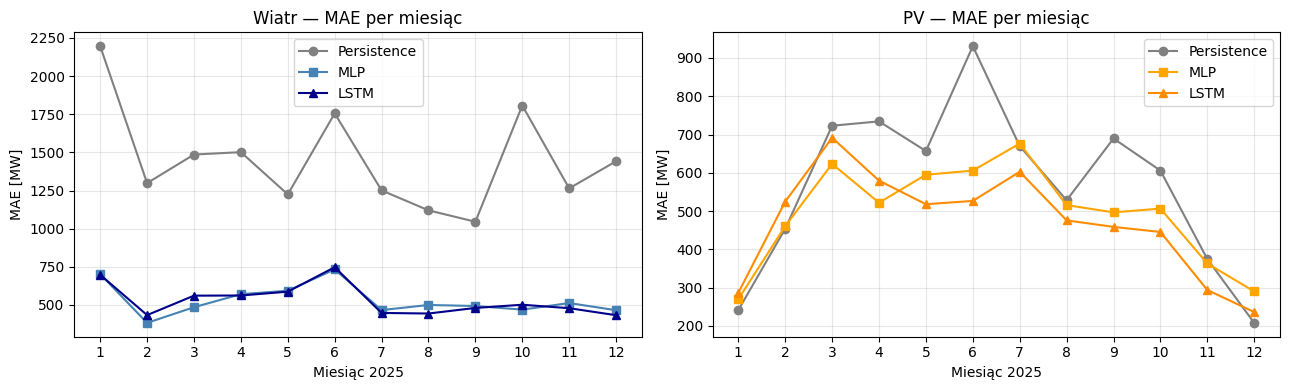

In [11]:
def monthly_mae(y_true, y_pred, ts):
    df_err = pd.DataFrame({
        "ts": ts,
        "wi_err": np.abs(y_true[:, :, 0] - y_pred[:, :, 0]).mean(axis=1),
        "pv_err": np.abs(y_true[:, :, 1] - y_pred[:, :, 1]).mean(axis=1),
    })
    df_err["month"] = pd.to_datetime(df_err["ts"]).dt.month
    return df_err.groupby("month")[["wi_err", "pv_err"]].mean()


monthly_pers = monthly_mae(y_test, y_pred_persistence, ts_test)
monthly_mlp  = monthly_mae(y_test, y_pred_mlp, ts_test)
monthly_lstm = monthly_mae(y_test, y_pred_lstm, ts_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(monthly_pers.index, monthly_pers["wi_err"], marker="o", label="Persistence", color="gray")
axes[0].plot(monthly_mlp.index,  monthly_mlp["wi_err"],  marker="s", label="MLP", color="steelblue")
axes[0].plot(monthly_lstm.index, monthly_lstm["wi_err"], marker="^", label="LSTM", color="darkblue")
axes[0].set_xlabel("Miesiąc 2025")
axes[0].set_ylabel("MAE [MW]")
axes[0].set_title("Wiatr — MAE per miesiąc")
axes[0].set_xticks(range(1, 13))
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(monthly_pers.index, monthly_pers["pv_err"], marker="o", label="Persistence", color="gray")
axes[1].plot(monthly_mlp.index,  monthly_mlp["pv_err"],  marker="s", label="MLP", color="orange")
axes[1].plot(monthly_lstm.index, monthly_lstm["pv_err"], marker="^", label="LSTM", color="darkorange")
axes[1].set_xlabel("Miesiąc 2025")
axes[1].set_ylabel("MAE [MW]")
axes[1].set_title("PV — MAE per miesiąc")
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Co widzimy w wykresie miesięcznym:**

Persistence dla wiatru ma duże wahania (1050-2200 MW MAE) - w styczniu MAE jest największe (~2200 MW), bo zimą wiatr jest silniejszy i bardziej zmienny, więc kopiowanie wczorajszej wartości daje większe błędy. MLP i LSTM mają stosunkowo płaski profil ~500 MW przez cały rok.

Dla PV: persistence ma niskie MAE w styczniu (najmniej generacji rocznie) i grudniu, ale wysokie latem (czerwiec-lipiec ~700-900 MW). MLP i LSTM mniej zmienne, ale też mają wzrost letni - bo wtedy generacja PV osiąga maksimum i absolutne błędy są naturalnie większe.

## 6.11 Analiza błędu per sezon

Grupujemy miesiące w sezony (zima/wiosna/lato/jesień) i liczymy MAE w każdym z nich. To daje czytelniejszy obraz niż 12 słupków per miesiąc.

In [12]:
def season_from_month(m):
    if m in [12, 1, 2]: return "zima"
    if m in [3, 4, 5]:  return "wiosna"
    if m in [6, 7, 8]:  return "lato"
    return "jesien"


def seasonal_mae(y_true, y_pred, ts):
    df_err = pd.DataFrame({
        "ts": ts,
        "wi_err": np.abs(y_true[:, :, 0] - y_pred[:, :, 0]).mean(axis=1),
        "pv_err": np.abs(y_true[:, :, 1] - y_pred[:, :, 1]).mean(axis=1),
    })
    df_err["season"] = pd.to_datetime(df_err["ts"]).dt.month.map(season_from_month)
    return df_err.groupby("season")[["wi_err", "pv_err"]].mean()


seasonal_pers = seasonal_mae(y_test, y_pred_persistence, ts_test)
seasonal_mlp  = seasonal_mae(y_test, y_pred_mlp,         ts_test)
seasonal_lstm = seasonal_mae(y_test, y_pred_lstm,        ts_test)

seasons_order = ["zima", "wiosna", "lato", "jesien"]

print("MAE wiatr per sezon [MW]:")
seasonal_table_wi = pd.DataFrame({
    "Persistence": seasonal_pers.loc[seasons_order, "wi_err"],
    "MLP":         seasonal_mlp.loc[seasons_order, "wi_err"],
    "LSTM":        seasonal_lstm.loc[seasons_order, "wi_err"],
}).round(1)
print(seasonal_table_wi)

print("\nMAE pv per sezon [MW]:")
seasonal_table_pv = pd.DataFrame({
    "Persistence": seasonal_pers.loc[seasons_order, "pv_err"],
    "MLP":         seasonal_mlp.loc[seasons_order, "pv_err"],
    "LSTM":        seasonal_lstm.loc[seasons_order, "pv_err"],
}).round(1)
print(seasonal_table_pv)

MAE wiatr per sezon [MW]:
        Persistence    MLP   LSTM
season                           
zima         1659.6  521.5  524.9
wiosna       1402.9  549.2  569.9
lato         1371.4  564.3  543.8
jesien       1376.9  491.1  486.8

MAE pv per sezon [MW]:
        Persistence    MLP   LSTM
season                           
zima          296.8  336.5  344.4
wiosna        704.4  580.6  596.4
lato          707.2  599.1  535.0
jesien        557.2  455.8  399.7


**Tabele MAE per sezon**

Dla wiatru wszystkie sezony są podobne - sieci dają ~490-570 MW MAE niezależnie od pory roku, persistence skacze od 1370 (jesień) do 1660 (zima). Sieci ładnie generalizują, dobrze radzą sobie i z chaotyczną zimą i ze spokojnym latem.

Dla PV pojawia się ciekawa rzecz - **zimą persistence jest lepsze od naszych sieci** (297 MW vs 336 MLP / 344 LSTM). To może wyglądać jak porażka, ale ma sens fizyczny: zimą generacja PV jest bardzo niska (krótkie dni, dużo chmur), więc kopiowanie wczorajszych wartości jest wystarczająco dobre. Sieci karmione prognozami pogody z błędem czasem przeszacowują generację, co przy małych wartościach absolutnych daje większy procent błędu.

Latem sytuacja się odwraca i LSTM wyraźnie wygrywa z MLP (535 vs 599 MW). Przy największej generacji LSTM lepiej radzi sobie z nieliniowościami (saturacja paneli przy maksimum, wpływ temperatury).

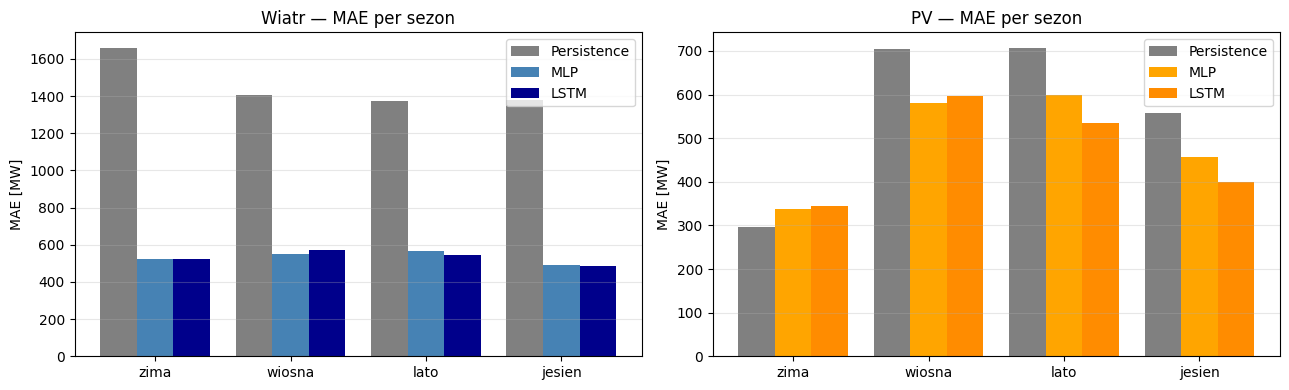

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(seasons_order))
width = 0.27

axes[0].bar(x - width, seasonal_table_wi["Persistence"], width, label="Persistence", color="gray")
axes[0].bar(x,         seasonal_table_wi["MLP"],         width, label="MLP", color="steelblue")
axes[0].bar(x + width, seasonal_table_wi["LSTM"],        width, label="LSTM", color="darkblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(seasons_order)
axes[0].set_ylabel("MAE [MW]")
axes[0].set_title("Wiatr — MAE per sezon")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(x - width, seasonal_table_pv["Persistence"], width, label="Persistence", color="gray")
axes[1].bar(x,         seasonal_table_pv["MLP"],         width, label="MLP", color="orange")
axes[1].bar(x + width, seasonal_table_pv["LSTM"],        width, label="LSTM", color="darkorange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(seasons_order)
axes[1].set_ylabel("MAE [MW]")
axes[1].set_title("PV — MAE per sezon")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Wykres słupkowy MAE per sezon widać który model w którym sezonie radzi sobie lepiej.

## 6.12 Analiza błędu per horyzont prognozy

Sieć przewiduje 24h naprzód jednym strzałem, ale błąd dla godziny 1 (najbliższa) i godziny 24 (najdalsza) może być różny. Sprawdzamy MAE dla każdej z 24 godzin horyzontu.

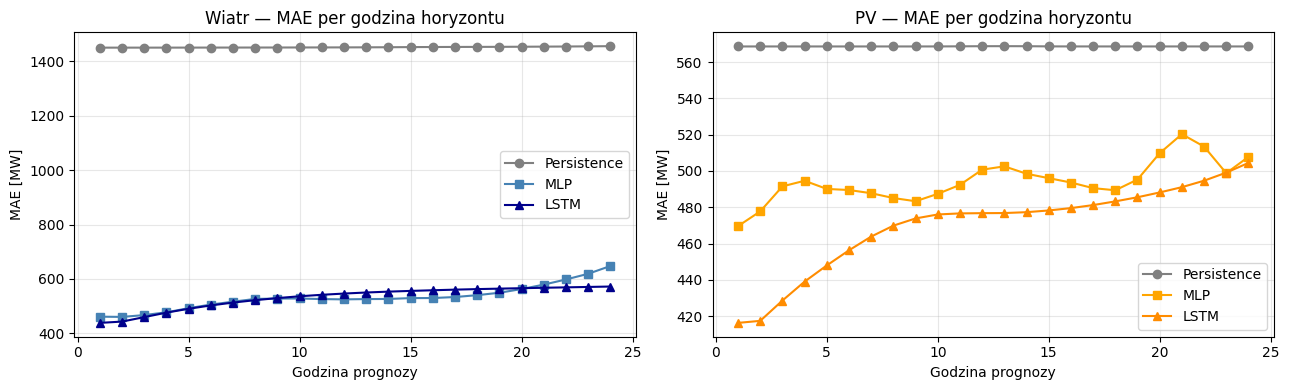

In [14]:
def horizon_mae(y_true, y_pred):
    mae_per_h = np.zeros((HORIZON, len(TARGETS)))
    for h in range(HORIZON):
        for i in range(len(TARGETS)):
            mae_per_h[h, i] = mean_absolute_error(y_true[:, h, i], y_pred[:, h, i])
    return mae_per_h


h_pers = horizon_mae(y_test, y_pred_persistence)
h_mlp  = horizon_mae(y_test, y_pred_mlp)
h_lstm = horizon_mae(y_test, y_pred_lstm)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, 25), h_pers[:, 0], marker="o", label="Persistence", color="gray")
axes[0].plot(range(1, 25), h_mlp[:, 0],  marker="s", label="MLP",         color="steelblue")
axes[0].plot(range(1, 25), h_lstm[:, 0], marker="^", label="LSTM",        color="darkblue")
axes[0].set_xlabel("Godzina prognozy")
axes[0].set_ylabel("MAE [MW]")
axes[0].set_title("Wiatr — MAE per godzina horyzontu")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, 25), h_pers[:, 1], marker="o", label="Persistence", color="gray")
axes[1].plot(range(1, 25), h_mlp[:, 1],  marker="s", label="MLP",         color="orange")
axes[1].plot(range(1, 25), h_lstm[:, 1], marker="^", label="LSTM",        color="darkorange")
axes[1].set_xlabel("Godzina prognozy")
axes[1].set_ylabel("MAE [MW]")
axes[1].set_title("PV — MAE per godzina horyzontu")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Co widzimy w wykresie per horyzont:**

Persistence to płaska linia w obu wykresach - kopiuje wczorajsze wartości, więc błąd jest taki sam dla każdej godziny prognozy.

Dla wiatru MLP i LSTM zachowują się prawie identycznie - MAE rośnie z ~430 MW dla pierwszej godziny do ~600-650 MW dla 24. godziny. To naturalne: im dalsza prognoza, tym większa niepewność (i prognoza pogody ma większy błąd, i sama dynamika atmosferyczna jest mniej przewidywalna w dłuższej skali).

Dla PV obraz jest bardziej skomplikowany. LSTM w pierwszych godzinach (1-5h) ma znacznie niższe MAE niż MLP (~420 vs 470 MW), ale od ~10. godziny zbiegają się i dla horyzontu 20-24h MLP jest nawet lekko lepszy. Falowanie krzywych odpowiada cyklowi dobowemu - godziny dnia (jasne) mają większe błędy niż noc (kiedy PV jest blisko zera i prognoza jest "łatwa"). LSTM lepiej przewiduje krótki horyzont, MLP dorównuje na dłuższym - to odzwierciedla różnice architektoniczne: LSTM ma większą "pamięć" ostatnich godzin, MLP traktuje całe okno jednolicie.

## 6.13 Najciekawsze przykłady

Pokazujemy konkretne dni - jeden z najgorszym błędem prognozy, jeden ze średnim, jeden z najlepszym. To daje konkretny wgląd w to **kiedy** modele zawodzą i kiedy świetnie sobie radzą.

In [15]:
errors_per_window = np.abs(y_test[:, :, 0] - y_pred_lstm[:, :, 0]).mean(axis=1)

idx_worst  = np.argmax(errors_per_window)
idx_best   = np.argmin(errors_per_window)
idx_median = np.argsort(errors_per_window)[len(errors_per_window) // 2]

print(f"Najgorszy:  {ts_test[idx_worst]}  (MAE wi: {errors_per_window[idx_worst]:.0f} MW)")
print(f"Średni:     {ts_test[idx_median]} (MAE wi: {errors_per_window[idx_median]:.0f} MW)")
print(f"Najlepszy:  {ts_test[idx_best]}   (MAE wi: {errors_per_window[idx_best]:.0f} MW)")

Najgorszy:  2025-07-10 02:00:00  (MAE wi: 1832 MW)
Średni:     2025-04-19 06:00:00 (MAE wi: 441 MW)
Najlepszy:  2025-09-06 19:00:00   (MAE wi: 80 MW)


Trzy dni do dokładniejszej analizy - wybrane na podstawie błędu LSTM dla wiatru.

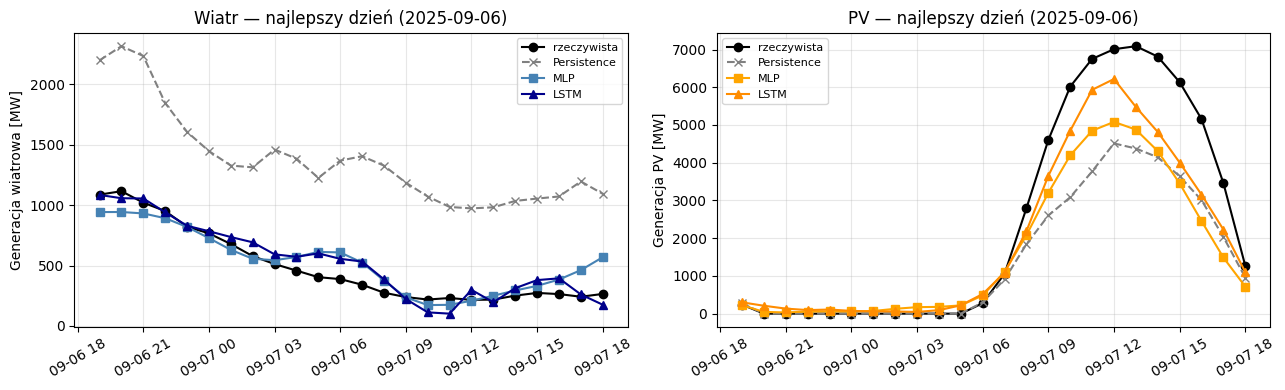

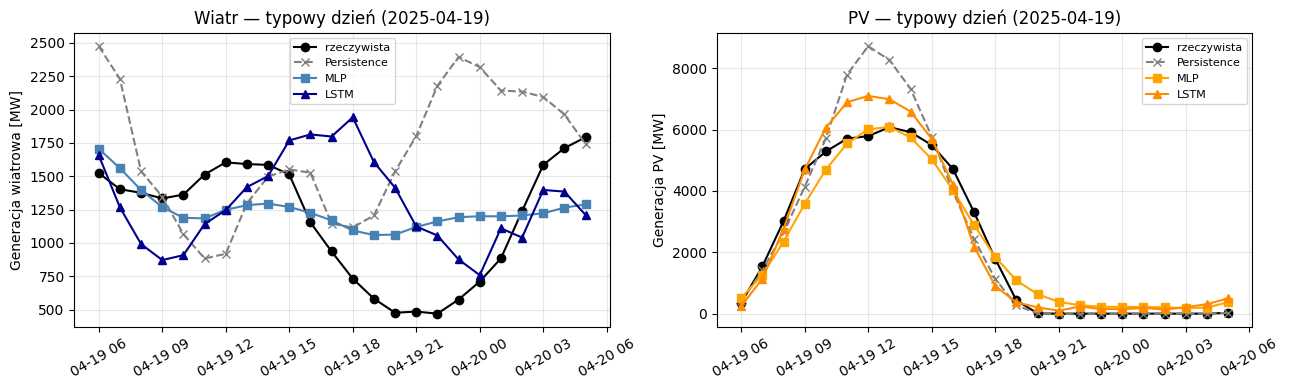

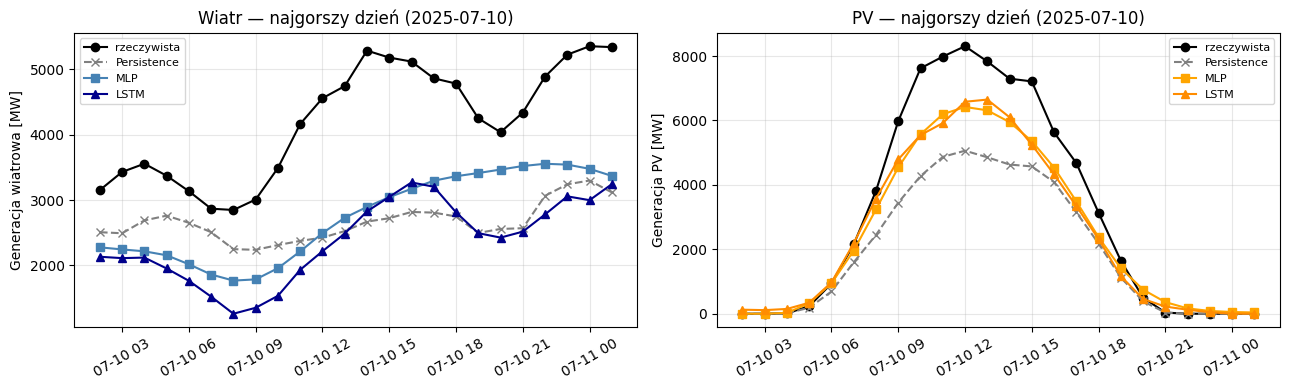

In [16]:
def plot_window(idx, title):
    t_start = ts_test[idx]
    hours = pd.date_range(t_start, periods=HORIZON, freq="1h")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(hours, y_test[idx, :, 0],         marker="o", color="black",      label="rzeczywista")
    axes[0].plot(hours, y_pred_persistence[idx, :, 0], marker="x", color="gray",    label="Persistence", linestyle="--")
    axes[0].plot(hours, y_pred_mlp[idx, :, 0],     marker="s", color="steelblue",  label="MLP")
    axes[0].plot(hours, y_pred_lstm[idx, :, 0],    marker="^", color="darkblue",   label="LSTM")
    axes[0].set_ylabel("Generacja wiatrowa [MW]")
    axes[0].set_title(f"Wiatr — {title}")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].plot(hours, y_test[idx, :, 1],         marker="o", color="black",      label="rzeczywista")
    axes[1].plot(hours, y_pred_persistence[idx, :, 1], marker="x", color="gray",    label="Persistence", linestyle="--")
    axes[1].plot(hours, y_pred_mlp[idx, :, 1],     marker="s", color="orange",     label="MLP")
    axes[1].plot(hours, y_pred_lstm[idx, :, 1],    marker="^", color="darkorange", label="LSTM")
    axes[1].set_ylabel("Generacja PV [MW]")
    axes[1].set_title(f"PV — {title}")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


plot_window(idx_best,   f"najlepszy dzień ({ts_test[idx_best].date()})")
plot_window(idx_median, f"typowy dzień ({ts_test[idx_median].date()})")
plot_window(idx_worst,  f"najgorszy dzień ({ts_test[idx_worst].date()})")

**Co widać na trzech przykładach:**

**Najlepszy dzień (6 września 2025).** Spokojny dzień gdzie generacja wiatrowa konsekwentnie spada przez dobę z 1100 do 200 MW. MLP i LSTM łapią tę krzywą prawie idealnie - błąd ~80 MW przy generacji ~500-1000 MW to świetny wynik. Persistence znowu kopiuje wczorajszą wartość (~2200 MW) i jest kompletnie obok. Dla PV mamy klasyczny słoneczny dzień, sieci dobrze przewidują kształt łuku ale lekko niedoszacowują maksimum (~5000-6000 MW vs 7000 MW rzeczywistych).

**Typowy dzień (19 kwietnia 2025).** Generacja wiatru oscyluje przez całą dobę (1500 → 500 → 1750 MW). Tu widać granice naszych modeli - łapią ogólny trend, ale szczegóły (gwałtowny spadek wieczorem i odbicie nad ranem) im umykają. Dla PV za to prawie perfekcyjne dopasowanie - kwietniowy słoneczny dzień modele przewidują z bardzo małym błędem.

**Najgorszy dzień (10 lipca 2025).** Tutaj rzeczywista generacja wiatru gwałtownie wzrasta z 3200 do 5500 MW (prawdopodobnie silny front wiatrowy), a wszystkie modele są **dramatycznie zaniżone** - przewidują tylko 2000-3500 MW. To kluczowa lekcja: gdy prognoza pogody nie wychwyciła silnego zjawiska atmosferycznego, sieć nie ma jak go przewidzieć - w końcu prognoza pogody jest jej jedynym wejściem o "przyszłości". Te 1832 MW MAE to skutek złej prognozy meteorologicznej, nie wady samej sieci. Dla PV podobny wzorzec - sieci znowu niedoszacowują maksimum (6500 vs 8000 MW).

Te trzy przykłady pokazują charakter błędu: w spokojnych warunkach modele są bardzo dobre, w typowych przewidują główne trendy ale gubią detale, w sytuacjach ekstremalnych są ograniczone jakością prognozy pogody.

## 6.14 Zapis predykcji testowych

In [17]:
predictions_test = pd.DataFrame({
    "timestamp": np.repeat(ts_test, HORIZON),
    "horizon": np.tile(np.arange(HORIZON), len(ts_test)),
    "wi_true": y_test[:, :, 0].flatten(),
    "pv_true": y_test[:, :, 1].flatten(),
    "wi_persistence": y_pred_persistence[:, :, 0].flatten(),
    "pv_persistence": y_pred_persistence[:, :, 1].flatten(),
    "wi_mlp": y_pred_mlp[:, :, 0].flatten(),
    "pv_mlp": y_pred_mlp[:, :, 1].flatten(),
    "wi_lstm": y_pred_lstm[:, :, 0].flatten(),
    "pv_lstm": y_pred_lstm[:, :, 1].flatten(),
})
predictions_test.to_csv(DATA_DIR / "predictions_test_06.csv", sep=";", decimal=",", index=False)

print(f"zapisano: {DATA_DIR / 'predictions_test_06.csv'}")
print(f"wierszy: {len(predictions_test)}")

zapisano: data/processed/predictions_test_06.csv
wierszy: 209664


Wszystkie predykcje testowe trzech modeli + ground truth zapisane w jednym CSV. Każdy wiersz to jedna godzina prognozy z konkretnego okna 24h, kolumna `horizon` mówi która to godzina (0-23) w prognozie.

## Podsumowanie projektu

### Co zrobiliśmy

Zbudowaliśmy model sieci neuronowej prognozujący godzinową generację energii wiatrowej (`wi`) i fotowoltaicznej (`pv`) w Krajowym Systemie Elektroenergetycznym na 24 godziny do przodu. Dane wejściowe to prognoza pogody dla 5 lokalizacji w Polsce (Szczecin, Słupsk, Bydgoszcz, Warszawa, Kraków) plus 48 godzin historii pogody i generacji.

Pełen pipeline: pobranie i czyszczenie danych z PSE i Open-Meteo (notebooki 01-02), eksploracja i łączenie zbiorów (notebook 03), zbudowanie i strojenie trzech rodzin modeli (notebooki 04-05), finałowy test na zbiorze 2025 z prognozami pogody (notebook 06).

### Podejście do danych

Najtrudniejszą decyzją okazało się rozdzielenie źródeł pogody. Dla okresu 2023-2024 użyliśmy reanalizy ERA5 z Open-Meteo Archive, czyli "co naprawdę było" po fakcie. Dla 2025 użyliśmy prognoz historycznych z Historical Forecast API, czyli "co prognozowano dnia poprzedniego". Trening i walidacja idą na ERA5, test na prognozach. Dzięki temu liczby finalne odpowiadają temu, czego operator systemu rzeczywiście doświadcza w produkcji.

Drugą ważną decyzją było rozszerzenie 7 zmiennych pogodowych razy 5 lokalizacji do 35 cech, plus konwersja kierunku wiatru na sin/cos (40 cech), plus cechy czasowe godziny i dnia roku w sin/cos. Mamy 46 cech wejściowych łącznie. Mniej cech (np. tylko jedna lokalizacja centralna) dawałoby gorszą reprezentatywność dla agregatu krajowego.

### Modele

Porównaliśmy trzy rodziny architektur:

1. **Persistence** - "jutro o godz. X tyle co dziś o godz. X". Bez modelu, czysty baseline.
2. **MLP** - klasyczna sieć gęsta, 875k parametrów, spłaszczone okno 48+24 godzin do wektora 3264 wartości.
3. **LSTM Encoder-Decoder** - wybrany po porównaniu dwóch wariantów LSTM (stacked vs encoder-decoder), oba strojone Bayesian Optimization. Tylko 20k parametrów trainable.

Dla porządku sprawdziliśmy też Linear Regression w 04, ale wyszło gorzej niż persistence dla PV (predykcje ujemne, brak ograniczeń fizycznych), więc nie braliśmy go do testu finalnego.

### Wyniki na walidacji

Walidację zrobiliśmy sezonowo zbalansowaną: 4 wycinki po 2 tygodnie z 2024 (luty, maj, sierpień, listopad). Dało nam to wgląd jak modele radzą sobie w różnych warunkach.

| Model | wi MAE | pv MAE |
|---|---|---|
| Persistence | 1498 MW | 514 MW |
| MLP | 437 MW | 373 MW |
| LSTM | 421 MW | 371 MW |

LSTM był lekko lepszy od MLP w obu kategoriach, ale głównie zaimponował mniejszą liczbą parametrów - 20k vs 875k. Architektura rekurencyjna jest po prostu lepiej dopasowana do szeregów czasowych.

### Wyniki na teście (cały 2025, prognozy pogody)

| Model | wi MAE | pv MAE |
|---|---|---|
| Persistence | 1451 MW | 569 MW |
| MLP | 532 MW | 494 MW |
| LSTM | 532 MW | 470 MW |

Persistence ma podobne MAE jak na walidacji, bo nie używa pogody. MLP i LSTM straciły 25-30% jakości w stosunku do walidacji, co odpowiada różnicy między ERA5 a prognozami pogodowymi. Mimo tego oba dramatycznie biją persistence: dla wiatru 532 MW vs 1451 MW (63% redukcji błędu), dla PV 470-494 vs 569 MW (15-17% redukcji).

W relatywnym ujęciu nasz najlepszy model LSTM osiąga MAE 21% w stosunku do średniej generacji w teście. To wpisuje się w typowe wyniki day-ahead OZE w literaturze (10-25%).

### Co zauważyliśmy w analizie

**Sezonowość**. Persistence dla wiatru ma dużo wyższe błędy zimą (1660 MW MAE) niż jesienią (1377 MW), bo zimowy wiatr jest silniejszy i bardziej zmienny. Sieci za to mają wyrównany profil 490-570 MW przez cały rok. Dla PV ciekawostka: zimą persistence jest LEPSZE od naszych sieci (297 MW vs 336-344 MW). Sieci karmione prognozami z błędem czasem przeszacowują niskie zimowe wartości, podczas gdy persistence "kopiuje" niskie wczorajsze wartości i jest bezpieczne. Latem sytuacja się odwraca i LSTM dramatycznie wygrywa z MLP (535 vs 599 MW) - lepiej radzi sobie z saturacją paneli przy maksymalnej generacji.

**Horyzont prognozy**. Błąd dla pierwszej godziny prognozy (~430 MW dla wiatru) rośnie do ~640 MW dla 24. godziny. Naturalny efekt: im dalsza prognoza, tym większa niepewność. Ciekawe że LSTM ma znacznie niższe MAE od MLP w pierwszych 5 godzinach, ale na dłuższym horyzoncie różnica się zaciera. To zaskoczyło nas pozytywnie - LSTM faktycznie wykorzystuje "pamięć" do precyzyjnej krótkoterminowej prognozy.

**Konkretne dni**. W najgorszym dniu (10 lipca 2025) generacja wiatrowa skoczyła z 3200 do 5500 MW, prawdopodobnie przez silny front. Wszystkie modele dramatycznie zaniżyły prognozę (predykcje 2000-3500 MW). To pokazuje granicę naszego podejścia: jeśli prognoza pogody nie wychwyciła zjawiska, sieć też go nie przewidzi. Z drugiej strony w najlepszym dniu (6 września 2025) MAE wynosiło tylko 80 MW dla wiatru - praktycznie idealna prognoza.

### Wnioski

Po pierwsze, deep learning ma sens w prognozie OZE. Nasze sieci redukują błąd 2-3 razy w stosunku do prostych baselinów, co przy mocy zainstalowanej rzędu kilkunastu GW przekłada się na konkretne oszczędności w bilansowaniu systemu.

Po drugie, mniejsze niekoniecznie znaczy gorsze. LSTM Encoder-Decoder osiąga porównywalne wyniki do MLP przy 40 razy mniejszej liczbie parametrów. Architektura ma znaczenie - rekurencyjna struktura naturalnie pasuje do szeregów czasowych i pozwala uniknąć przepychania siecią informacji, którą może zakodować efektywniej.

Po trzecie, jakość prognozy pogody to twardy limit. Spadek MAE o 25-30% między walidacją na ERA5 a testem na prognozach pokazuje, że nasza sieć może być tylko tak dobra, jak dane wejściowe. W realnej produkcji błąd modelu pogodowego (np. niewychwycenie frontu) bezpośrednio przekłada się na błąd prognozy generacji.

Po czwarte, wiatr i PV wymagają różnych podejść. Wiatr jest chaotyczny, silnie zależny od pogody synoptycznej, ma minimalny cykl dobowy. PV ma silny cykl dobowy i roczny, ale latem dochodzi nieliniowość saturacji paneli. Modele traktujące oba targety identycznie (jak nasz wspólny MLP/LSTM) działają, ale prawdopodobnie osobne sieci dla każdego targetu dałyby jeszcze lepsze wyniki.

Projekt domknął się na 26 304 godzinach danych historycznych, 5 lokalizacjach pogodowych, 3 modelach i finalnym MAE 532 MW dla wiatru i 470 MW dla PV w warunkach produkcyjnych.